# Synoptic Metadata Enrichment and Variable Availability Audit (Idaho)

This notebook enriches the Idaho Synoptic station inventory with detailed metadata retrieved from the Synoptic Weather API (`stations/metadata`, with `complete=1` and `sensorvars=1`). The goal is to characterize not only which stations are present in Synoptic, but also what *variables and sensor configurations* are available, and how long each variable has been reported (Period of Record, POR).

## Key questions
- What variables are reported by Synoptic stations in Idaho, and with what sensor heights/depths?
- How complete is the metadata returned by Synoptic (e.g., missing POR, missing heights)?
- How does data availability (POR duration) vary by network (MNET_ID) and by variable family?

## Outputs
- `out/synoptic_station_enriched.csv`: station-level metadata (location, elevation, network_id, providers, siting, POR, restrictions).
- `out/synoptic_variable_enriched.csv`: variable/sensor-level metadata (variable family/native name, unit, height/depth, dimension, POR).
- `out/period_of_record_stats_by_network.csv`: network-level summary statistics of POR duration.

The notebook performs a Phase 1 hydro-meteorological network audit for Idaho, integrating multiple observational networks to:
- Identify overlaps
- Detect redundancies
- Quantify gaps
- Evaluate integration potential

It focuses on:
- Synoptic




In [1]:
import os
os.environ["SYNOPTIC_TOKEN"] = "XXXX"

### Setup and helper functions

This section:
- loads required inputs (the combined stations inventory from phase 1),
- reads the Synoptic API token from an environment variable (never hard-code credentials),
- defines endpoints and local cache directories,
- provides robust HTTP + caching utilities to avoid repeated API calls,
- defines parsers that convert nested Synoptic JSON into clean station-level and variable-level rows.

In [2]:
import os, json, time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)

STATIONS_ALL_CSV = os.path.join(OUT_DIR, "stations_all.csv")
assert os.path.exists(STATIONS_ALL_CSV), "Missing out/stations_all.csv (run notebook 1 first)."

SYNOPTIC_TOKEN = os.getenv("SYNOPTIC_TOKEN", "").strip()
assert SYNOPTIC_TOKEN, "Set env var SYNOPTIC_TOKEN first."

SYN_STATION_METADATA = "https://api.synopticdata.com/v2/stations/metadata"

CACHE_DIR = os.path.join(OUT_DIR, "cache_synoptic_metadata_complete")
os.makedirs(CACHE_DIR, exist_ok=True)

OUT_STATION_ENRICHED = os.path.join(OUT_DIR, "synoptic_station_enriched.csv")
OUT_VAR_ENRICHED     = os.path.join(OUT_DIR, "synoptic_variable_enriched.csv")

OUT_BASELINE_BY_NET  = os.path.join(OUT_DIR, "observational_metadata_baseline_by_network.csv")

REQUEST_TIMEOUT = 60
RETRIES = 3
SLEEP_S = 0.12   # be polite

In [3]:
def cache_path_for_stid(stid: str) -> str:
    safe = "".join([c for c in stid if c.isalnum() or c in ("_", "-")])
    # include flags in filename so cached responses match request shape
    return os.path.join(CACHE_DIR, f"{safe}__complete1__sensorvars1.json")

def safe_get_json(url: str, params: dict, cache_path: str, timeout: int = 60, retries: int = 3) -> dict:
    if os.path.exists(cache_path):
        with open(cache_path, "r") as f:
            return json.load(f)

    last_err = None
    for i in range(retries):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            r.raise_for_status()
            js = r.json()
            with open(cache_path, "w") as f:
                json.dump(js, f, ensure_ascii=False)
            return js
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (i + 1))
    raise RuntimeError(f"Synoptic GET failed after {retries} retries. params={params} err={last_err}")

def fetch_synoptic_metadata_complete(stid: str) -> dict:
    params = {
        "stid": stid,
        "token": SYNOPTIC_TOKEN,
        "complete": 1,
        "sensorvars": 1,
    }
    return safe_get_json(
        SYN_STATION_METADATA,
        params=params,
        cache_path=cache_path_for_stid(stid),
        timeout=REQUEST_TIMEOUT,
        retries=RETRIES
    )

In [4]:
def to_json_or_na(x):
    if x is None:
        return pd.NA
    try:
        # store {} as NA? No: keep '{}' to distinguish "present but empty"
        return json.dumps(x, ensure_ascii=False)
    except Exception:
        return pd.NA

def parse_station_row(js: dict) -> dict:
    st = (js.get("STATION") or [{}])[0]
    stid = st.get("STID")
    return {
        "station_uid": f"SYNOPTIC:{stid}" if stid else pd.NA,
        "source": "SYNOPTIC",
        "source_station_id": stid,
        "station_name": st.get("NAME"),
        "latitude": pd.to_numeric(st.get("LATITUDE"), errors="coerce"),
        "longitude": pd.to_numeric(st.get("LONGITUDE"), errors="coerce"),
        "elevation_m": pd.to_numeric(st.get("ELEVATION"), errors="coerce"),
        "network_id": str(st.get("MNET_ID")).strip() if st.get("MNET_ID") is not None else pd.NA,
        "timezone": st.get("TIMEZONE"),
        "county": st.get("COUNTY"),
        "providers_json": to_json_or_na(st.get("PROVIDERS")),
        "siting_json": to_json_or_na(st.get("SITING")),
        "period_of_record_json": to_json_or_na(st.get("PERIOD_OF_RECORD")),
        "restricted": st.get("RESTRICTED"),
        "restricted_metadata": st.get("RESTRICTED_METADATA"),
    }
def parse_variable_rows(js: dict) -> list[dict]:
    st = (js.get("STATION") or [{}])[0]
    stid = st.get("STID")
    station_uid = f"SYNOPTIC:{stid}" if stid else pd.NA
    network_id = str(st.get("MNET_ID")).strip() if st.get("MNET_ID") is not None else pd.NA

    units = st.get("UNITS") or {}
    sensor_vars = st.get("SENSOR_VARIABLES") or {}

    rows = []

    # If SENSOR_VARIABLES is not a dict, store raw and return
    if not isinstance(sensor_vars, dict):
        rows.append({
            "station_uid": station_uid,
            "source": "SYNOPTIC",
            "source_station_id": stid,
            "network_id": network_id,
            "variable_family": "__raw__",
            "variable_native": "__raw__",
            "unit": pd.NA,
            "sensor_height_m": pd.NA,
            "sensor_depth_m": pd.NA,
            "position": pd.NA,
            "dimension_json": to_json_or_na({}),
            "period_of_record_json": pd.NA,
            "source_details_json": to_json_or_na(sensor_vars),
        })
        return rows

    for family, fam_payload in sensor_vars.items():
        if fam_payload is None:
            continue

        # Normal case: fam_payload should be dict of sensors
        if isinstance(fam_payload, dict):

            for sensor_key, sensor_payload in fam_payload.items():

                # sensor_payload might be dict OR string/other — normalize
                if not isinstance(sensor_payload, dict):
                    rows.append({
                        "station_uid": station_uid,
                        "source": "SYNOPTIC",
                        "source_station_id": stid,
                        "network_id": network_id,
                        "variable_family": family,
                        "variable_native": sensor_key,
                        "unit": units.get(sensor_key) or units.get(family) or pd.NA,
                        "sensor_height_m": pd.NA,
                        "sensor_depth_m": pd.NA,
                        "position": pd.NA,
                        "dimension_json": pd.NA,
                        "period_of_record_json": pd.NA,
                        "source_details_json": to_json_or_na(sensor_payload),
                    })
                    continue

                unit = units.get(sensor_key) or units.get(family) or pd.NA

                pos = sensor_payload.get("position")
                dim = sensor_payload.get("dimension") if isinstance(sensor_payload.get("dimension"), dict) else {}
                summary = sensor_payload.get("summary")
                if not isinstance(summary, dict):
                    summary = {}

                # height/depth can appear in payload or inside summary
                height = sensor_payload.get("height") if sensor_payload.get("height") is not None else summary.get("height")
                depth  = sensor_payload.get("depth")  if sensor_payload.get("depth")  is not None else summary.get("depth")

                # period of record may appear in various places
                por = (
                    sensor_payload.get("PERIOD_OF_RECORD")
                    or sensor_payload.get("period_of_record")
                    or sensor_payload.get("por")
                    or summary.get("PERIOD_OF_RECORD")
                    or summary.get("period_of_record")
                )

                rows.append({
                    "station_uid": station_uid,
                    "source": "SYNOPTIC",
                    "source_station_id": stid,
                    "network_id": network_id,
                    "variable_family": family,
                    "variable_native": sensor_key,
                    "unit": unit,
                    "sensor_height_m": pd.to_numeric(height, errors="coerce") if height is not None else pd.NA,
                    "sensor_depth_m": pd.to_numeric(depth, errors="coerce") if depth is not None else pd.NA,
                    "position": pos if pos is not None else pd.NA,
                    "dimension_json": to_json_or_na(dim),
                    "period_of_record_json": to_json_or_na(por),
                    "source_details_json": to_json_or_na(sensor_payload),
                })

        else:
            # Unexpected structure for family payload (string/list/etc)
            rows.append({
                "station_uid": station_uid,
                "source": "SYNOPTIC",
                "source_station_id": stid,
                "network_id": network_id,
                "variable_family": family,
                "variable_native": family,
                "unit": units.get(family) or pd.NA,
                "sensor_height_m": pd.NA,
                "sensor_depth_m": pd.NA,
                "position": pd.NA,
                "dimension_json": pd.NA,
                "period_of_record_json": pd.NA,
                "source_details_json": to_json_or_na(fam_payload),
            })

    return rows


## Synoptic metadata enrichment (station + variable tables)

This section:
- filters the master inventory to Synoptic stations only,
- loops over station IDs (STID) and calls the Synoptic `stations/metadata` endpoint,
- caches each response to disk for reproducibility and speed,
- appends parsed station rows and variable rows,
- supports resuming from previous outputs or rebuilding from scratch,
- writes final enriched CSVs for station metadata and variable metadata.

In [5]:
# ============================================================
# CELL 4 — Synoptic Metadata Enrichment (Robust Version)
# ============================================================

REBUILD_ALL = False               # True = rifà tutto (stazioni + variabili)
REBUILD_VARIABLES_ONLY = True   # True = rifà solo variabili

# ------------------------------------------------------------
# Load stations to enrich
# ------------------------------------------------------------

stations_all = pd.read_csv(STATIONS_ALL_CSV)

syn = stations_all[stations_all["source"] == "SYNOPTIC"].copy()
syn = syn.dropna(subset=["source_station_id"]).copy()
stids = sorted(syn["source_station_id"].astype(str).str.strip().unique())

print("Synoptic stations to enrich:", len(stids))

# ------------------------------------------------------------
# Determine resume state
# ------------------------------------------------------------

already = set()

if not REBUILD_ALL:
    if os.path.exists(OUT_STATION_ENRICHED):
        try:
            prev = pd.read_csv(OUT_STATION_ENRICHED)
            already = set(
                prev["source_station_id"]
                .dropna()
                .astype(str)
                .str.strip()
                .unique()
            )
            print("Resume mode — already enriched:", len(already))
        except Exception:
            already = set()

# ------------------------------------------------------------
# Load existing rows safely
# ------------------------------------------------------------

station_rows = []
var_rows = []

if not REBUILD_ALL:
    if os.path.exists(OUT_STATION_ENRICHED):
        try:
            station_rows = pd.read_csv(OUT_STATION_ENRICHED).to_dict("records")
        except Exception:
            station_rows = []

    if os.path.exists(OUT_VAR_ENRICHED):
        try:
            var_rows = pd.read_csv(OUT_VAR_ENRICHED).to_dict("records")
        except Exception:
            var_rows = []

# ------------------------------------------------------------
# Optional rebuild logic
# ------------------------------------------------------------

if REBUILD_ALL:
    print("Rebuilding EVERYTHING from scratch...")
    station_rows = []
    var_rows = []
    already = set()

elif REBUILD_VARIABLES_ONLY:
    print("Rebuilding VARIABLE metadata only...")
    var_rows = []
    already = set()  # force re-fetch

# ------------------------------------------------------------
# Main enrichment loop
# ------------------------------------------------------------

n_done = 0

for stid in stids:

    if stid in already:
        continue

    js = fetch_synoptic_metadata_complete(stid)

    if not js.get("STATION"):
        continue

    station_rows.append(parse_station_row(js))
    var_rows.extend(parse_variable_rows(js))

    n_done += 1

    if n_done % 50 == 0:
        print(f"Enriched {n_done} new stations... saving checkpoint")

        pd.DataFrame(station_rows) \
            .drop_duplicates(subset=["source_station_id"]) \
            .to_csv(OUT_STATION_ENRICHED, index=False)

        pd.DataFrame(var_rows) \
            .drop_duplicates(subset=["station_uid","variable_family","variable_native","position","sensor_height_m","sensor_depth_m"])\
            .to_csv(OUT_VAR_ENRICHED, index=False)

    time.sleep(SLEEP_S)

# ------------------------------------------------------------
# Final save
# ------------------------------------------------------------

df_station_enr = (
    pd.DataFrame(station_rows)
    .drop_duplicates(subset=["source_station_id"])
    .reset_index(drop=True)
)

df_var_enr = (
    pd.DataFrame(var_rows)
    .drop_duplicates(subset=["station_uid","variable_family","variable_native","position","sensor_height_m","sensor_depth_m"])   
    .reset_index(drop=True)
)

df_station_enr.to_csv(OUT_STATION_ENRICHED, index=False)
df_var_enr.to_csv(OUT_VAR_ENRICHED, index=False)

print("[OUT]", OUT_STATION_ENRICHED, len(df_station_enr))
print("[OUT]", OUT_VAR_ENRICHED, len(df_var_enr))

df_station_enr.head()

Synoptic stations to enrich: 1175
Resume mode — already enriched: 1175
Rebuilding VARIABLE metadata only...
Enriched 50 new stations... saving checkpoint
Enriched 100 new stations... saving checkpoint
Enriched 150 new stations... saving checkpoint
Enriched 200 new stations... saving checkpoint
Enriched 250 new stations... saving checkpoint
Enriched 300 new stations... saving checkpoint
Enriched 350 new stations... saving checkpoint
Enriched 400 new stations... saving checkpoint
Enriched 450 new stations... saving checkpoint
Enriched 500 new stations... saving checkpoint
Enriched 550 new stations... saving checkpoint
Enriched 600 new stations... saving checkpoint
Enriched 650 new stations... saving checkpoint
Enriched 700 new stations... saving checkpoint
Enriched 750 new stations... saving checkpoint
Enriched 800 new stations... saving checkpoint
Enriched 850 new stations... saving checkpoint
Enriched 900 new stations... saving checkpoint
Enriched 950 new stations... saving checkpoint


,station_uid,source,source_station_id,station_name,latitude,longitude,elevation_m,network_id,timezone,county,providers_json,siting_json,period_of_record_json,restricted,restricted_metadata
0,SYNOPTIC:001ID,SYNOPTIC,001ID,E2T13,45.02195,-113.68215,4786.0,317,America/Boise,Lemhi,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
1,SYNOPTIC:002ID,SYNOPTIC,002ID,E2T15,45.07377,-113.63931,5362.0,317,America/Boise,Lemhi,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
2,SYNOPTIC:003ID,SYNOPTIC,003ID,W2T26,44.30781,-115.98540,4884.0,317,America/Boise,Valley,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
3,SYNOPTIC:004ID,SYNOPTIC,004ID,W2T31,44.42516,-115.99145,4765.0,317,America/Boise,Valley,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False
4,SYNOPTIC:005ID,SYNOPTIC,005ID,W3T2,44.47213,-116.05862,4838.0,317,America/Boise,Valley,[],[],"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...",False,False


## Period of Record (POR) analysis

This section:
- extracts start/end timestamps from each variable's `period_of_record_json`,
- computes a POR duration in years (`por_years`),
- aggregates POR statistics by network_id (MNET_ID),
- saves network-level POR summaries for reporting.

Note: POR metadata quality varies by network and variable; this analysis focuses on metadata completeness and relative differences, not on time-series quality.

In [6]:
# -----------------------------
# Cell 5 — Period of Record analysis (quality, not just presence)
# -----------------------------

import json
import numpy as np

# 1) Extract record duration in years
def extract_por_years(por_json):
    if pd.isna(por_json):
        return np.nan
    try:
        d = json.loads(por_json)
        if not isinstance(d, dict):
            return np.nan

        # common patterns
        start = d.get("start") or d.get("first") or d.get("begin")
        end   = d.get("end")   or d.get("last")  or d.get("finish")

        # sometimes nested
        if isinstance(d.get("range"), dict):
            start = start or d["range"].get("start") or d["range"].get("first")
            end   = end   or d["range"].get("end")   or d["range"].get("last")

        start = pd.to_datetime(start, errors="coerce")
        end   = pd.to_datetime(end, errors="coerce")
        if pd.isna(start) or pd.isna(end):
            return np.nan
        return (end - start).days / 365.25
    except Exception:
        return np.nan

df_var_enr["por_years"] = df_var_enr["period_of_record_json"].apply(extract_por_years)

print("POR extracted. Example values:")
display(df_var_enr["por_years"].describe())

# 2) Aggregate by network
por_by_network = (
    df_var_enr
    .groupby("network_id")["por_years"]
    .agg([
        ("mean_por_years", "mean"),
        ("median_por_years", "median"),
        ("max_por_years", "max"),
        ("min_por_years", "min")
    ])
    .reset_index()
    .sort_values("mean_por_years", ascending=False)
)

display(por_by_network.head(12))

# 3) Save for report
por_by_network.to_csv(os.path.join(OUT_DIR, "period_of_record_stats_by_network.csv"), index=False)

print("[OUT] period_of_record_stats_by_network.csv")

POR extracted. Example values:


count    11348.000000
mean        10.779465
std          9.377837
min         -0.711841
25%          2.830938
50%          8.607803
75%         17.765914
max         29.127995
Name: por_years, dtype: float64

,network_id,mean_por_years,median_por_years,max_por_years,min_por_years
0,1,24.406459,28.851472,29.127995,0.027379
12,25,18.140766,22.253251,26.078029,0.021903
9,2,17.724308,17.379877,29.127995,-0.002738
3,11,15.066903,17.366188,26.198494,-0.002738
30,64,14.583162,13.278576,22.494182,3.906913
7,138,11.792670,8.585900,26.069815,-0.002738
14,29,11.739122,12.777550,15.671458,4.106776
4,123,11.657617,11.857632,19.173169,0.407940
25,41,11.492909,9.478439,24.933607,-0.711841
28,6,11.491974,10.193018,27.575633,-0.002738


[OUT] period_of_record_stats_by_network.csv


## Variable Coverage Across Synoptic Stations (Idaho)

This figure shows the number of Synoptic stations in Idaho reporting each native variable.  
It provides an overview of variable availability across the network, highlighting which measurements are widely deployed and which are sparse or limited to specific networks.

Interpreting this plot allows us to:
- Identify the most operationally robust variables (high station count),
- Detect specialized or rarely deployed sensors,
- Assess the overall observational capacity of the Synoptic network beyond simple station counts.

This analysis focuses on *station-level availability* rather than data completeness or quality.

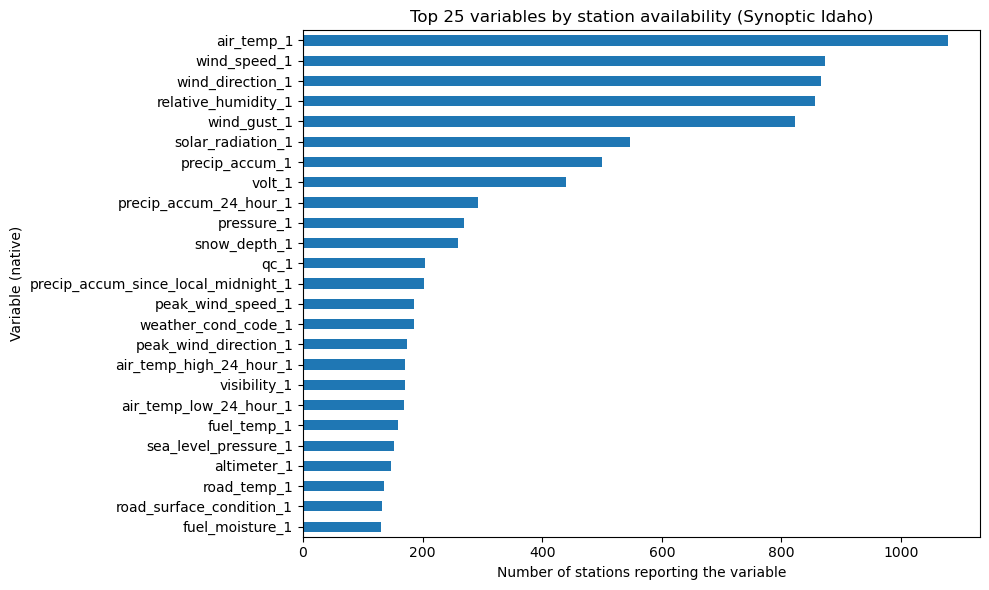

In [7]:
# Count stations per variable (native)
var_station_counts = (
    df_var_enr
    .groupby("variable_native")["station_uid"]
    .nunique()
    .sort_values(ascending=False)
)

topN = 25
plt.figure(figsize=(10,6))
var_station_counts.head(topN).iloc[::-1].plot(kind="barh")
plt.xlabel("Number of stations reporting the variable")
plt.ylabel("Variable (native)")
plt.title(f"Top {topN} variables by station availability (Synoptic Idaho)")
plt.tight_layout()
plt.show()

The distribution of reported variables reveals a strongly meteorology-centered network structure. Core atmospheric variables (air temperature, wind speed/direction, relative humidity) are widely available, indicating robust operational meteorological coverage. 

In contrast, cryospheric variables such as snow depth are limited to a smaller subset of stations, reflecting the heterogeneous purposes of contributing networks (e.g., RWIS, airport, fire-weather stations).

Because native variable names reflect sensor-level distinctions rather than physical-variable families, further aggregation by variable family is recommended to obtain a clearer picture of observational capacity.

In [8]:
import re
import numpy as np

def classify_physical_family(varname: str) -> str:
    """
    Map Synoptic native variable names to physical variable families.
    Rule-based classification using keyword matching.
    """

    if pd.isna(varname):
        return np.nan

    v = varname.lower()

    # --- Temperature ---
    if re.search(r"(air_temp|temp_|_temp|temperature)", v):
        if "ground" in v or "soil" in v:
            return "GROUND_TEMPERATURE"
        if "road" in v:
            return "ROAD_TEMPERATURE"
        if "fuel" in v:
            return "FUEL_TEMPERATURE"
        return "AIR_TEMPERATURE"

    # --- Wind ---
    if "wind_speed" in v or "wind_gust" in v or "peak_wind_speed" in v:
        return "WIND_SPEED"
    if "wind_direction" in v:
        return "WIND_DIRECTION"

    # --- Humidity ---
    if "relative_humidity" in v or v.startswith("rh"):
        return "RELATIVE_HUMIDITY"

    # --- Radiation ---
    if "solar_radiation" in v:
        return "SOLAR_RADIATION"

    # --- Precipitation ---
    if "precip" in v:
        return "PRECIPITATION"

    # --- Snow ---
    if "snow_depth" in v:
        return "SNOW_DEPTH"
    if "swe" in v:
        return "SNOW_WATER_EQUIVALENT"

    # --- Pressure ---
    if "pressure" in v or "altimeter" in v:
        return "PRESSURE"

    # --- Visibility ---
    if "visibility" in v:
        return "VISIBILITY"

    # --- Surface condition ---
    if "road_surface_condition" in v:
        return "ROAD_SURFACE_CONDITION"

    # --- Fuel moisture ---
    if "fuel_moisture" in v:
        return "FUEL_MOISTURE"

    # --- Fallback ---
    return "OTHER"

In [9]:
df_var_enr["physical_family"] = df_var_enr["variable_native"].apply(classify_physical_family)

# Controllo distribuzione
family_counts = (
    df_var_enr
    .groupby("physical_family")["station_uid"]
    .nunique()
    .sort_values(ascending=False)
)

family_counts

physical_family
AIR_TEMPERATURE           1093
PRECIPITATION              880
WIND_SPEED                 873
WIND_DIRECTION             866
RELATIVE_HUMIDITY          856
OTHER                      845
SOLAR_RADIATION            546
PRESSURE                   421
SNOW_DEPTH                 259
VISIBILITY                 170
FUEL_TEMPERATURE           159
ROAD_TEMPERATURE           140
ROAD_SURFACE_CONDITION     139
FUEL_MOISTURE              131
GROUND_TEMPERATURE          87
Name: station_uid, dtype: int64

## Physical Variable Coverage Across Synoptic Stations (Idaho)

This figure summarizes the number of Synoptic stations in Idaho reporting each **physical variable family**, after aggregating native sensor-level variables into broader meteorological categories.

Unlike the previous plot based on native variable names (e.g., `air_temp_1`, `air_temp_2`), this classification reflects the *actual physical measurement capability* of the network.

### Key Observations

- **Core atmospheric variables** (Air Temperature, Wind Speed, Wind Direction, Relative Humidity) are the most widely available across the network, indicating strong operational meteorological coverage.
  
- **Precipitation and Solar Radiation** show intermediate coverage, suggesting partial but not universal deployment across contributing networks.

- **Snow-related variables** (e.g., Snow Depth) are available at a smaller subset of stations, reflecting the heterogeneous nature of the Synoptic network and its integration of non-cryospheric station types (e.g., RWIS, airport, fire-weather stations).

- **Specialized measurements** (e.g., Road Temperature, Fuel Moisture, Road Surface Condition) are limited to niche networks and serve specific operational domains.

### Interpretation

This aggregation provides a clearer picture of the *observational capacity* of the Synoptic network.  
Rather than counting individual sensors, it reveals which physical processes are robustly monitored statewide and which are spatially sparse.


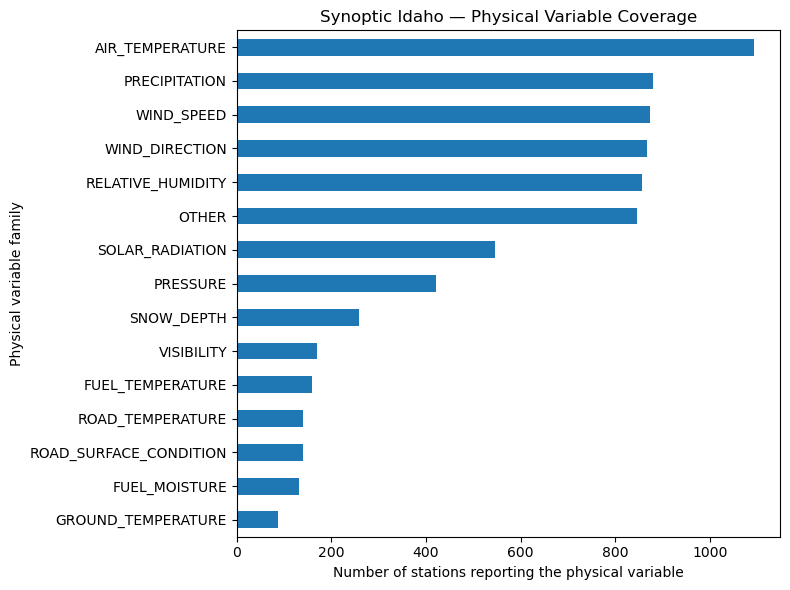

In [10]:
plt.figure(figsize=(8,6))

family_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of stations reporting the physical variable")
plt.ylabel("Physical variable family")
plt.title("Synoptic Idaho — Physical Variable Coverage")
plt.tight_layout()
plt.show()

## Interpretation

The Synoptic network in Idaho provides extensive coverage for core atmospheric variables, including air temperature, wind speed and direction, relative humidity, and precipitation. These measurements are reported by the majority of stations, indicating strong meteorological monitoring capacity.

Solar radiation and pressure are available at a moderate number of stations, while snow-related variables such as snow depth are present in a smaller subset.

Specialized variables (e.g., road temperature, fuel moisture, road surface condition) are limited to specific operational networks and are not broadly deployed statewide.

Overall, the network demonstrates broad atmospheric coverage, with more limited availability for cryospheric and specialized measurements.Structural Insight

This plot demonstrates that Synoptic Idaho:
- Is highly robust for atmospheric monitoring
- Provides moderate radiation coverage
- Has limited snow and hydrologic specialization
- Integrates multiple operational network types

From a network-design perspective:
- It is well suited for weather monitoring and short-term forecasting.
- It is less structurally aligned with cryospheric or hydrologic climatology ( integration with full SNOTEL can be helpful)

In [11]:
df_var_enr

,station_uid,source,source_station_id,network_id,variable_family,variable_native,unit,sensor_height_m,sensor_depth_m,position,dimension_json,period_of_record_json,source_details_json,por_years,physical_family
0,SYNOPTIC:001ID,SYNOPTIC,001ID,317,air_temp,air_temp_1,<NA>,<NA>,<NA>,<NA>,{},"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...","{""position"": null, ""dimension"": {}, ""summary"":...",0.700890,AIR_TEMPERATURE
1,SYNOPTIC:001ID,SYNOPTIC,001ID,317,relative_humidity,relative_humidity_1,<NA>,<NA>,<NA>,<NA>,{},"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...","{""position"": null, ""dimension"": {}, ""summary"":...",0.700890,RELATIVE_HUMIDITY
2,SYNOPTIC:001ID,SYNOPTIC,001ID,317,wind_speed,wind_speed_1,<NA>,<NA>,<NA>,<NA>,{},"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...","{""position"": null, ""dimension"": {}, ""summary"":...",0.700890,WIND_SPEED
3,SYNOPTIC:001ID,SYNOPTIC,001ID,317,wind_direction,wind_direction_1,<NA>,<NA>,<NA>,<NA>,{},"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...","{""position"": null, ""dimension"": {}, ""summary"":...",0.700890,WIND_DIRECTION
4,SYNOPTIC:001ID,SYNOPTIC,001ID,317,wind_gust,wind_gust_1,<NA>,<NA>,<NA>,<NA>,{},"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026...","{""position"": null, ""dimension"": {}, ""summary"":...",0.700890,WIND_SPEED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11669,SYNOPTIC:YFFI1,SYNOPTIC,YFFI1,2,fuel_temp,fuel_temp_1,<NA>,<NA>,<NA>,0.3,{},"{""start"": ""1998-07-28T00:00:00Z"", ""end"": ""2013...","{""position"": ""0.3"", ""dimension"": {}, ""summary""...",14.836413,FUEL_TEMPERATURE
11670,SYNOPTIC:YFFI1,SYNOPTIC,YFFI1,2,fuel_moisture,fuel_moisture_1,<NA>,<NA>,<NA>,0.3,{},"{""start"": ""1998-07-28T00:00:00Z"", ""end"": ""2013...","{""position"": ""0.3"", ""dimension"": {}, ""summary""...",14.836413,FUEL_MOISTURE
11671,SYNOPTIC:YFFI1,SYNOPTIC,YFFI1,2,volt,volt_1,<NA>,<NA>,<NA>,<NA>,{},"{""start"": ""1998-07-28T00:00:00Z"", ""end"": ""2026...","{""position"": null, ""dimension"": {}, ""summary"":...",27.559206,OTHER
11672,SYNOPTIC:YFFI1,SYNOPTIC,YFFI1,2,snow_interval,snow_interval_1,<NA>,<NA>,<NA>,<NA>,{},"{""start"": ""1998-07-28T00:00:00Z"", ""end"": ""2011...","{""position"": null, ""dimension"": {}, ""summary"":...",12.780287,OTHER


In [12]:
df_var_enr.columns

Index(['station_uid', 'source', 'source_station_id', 'network_id',
       'variable_family', 'variable_native', 'unit', 'sensor_height_m',
       'sensor_depth_m', 'position', 'dimension_json', 'period_of_record_json',
       'source_details_json', 'por_years', 'physical_family'],
      dtype='object')

In [13]:
import json
import numpy as np

def extract_por_years(por_json):
    if pd.isna(por_json):
        return np.nan
    try:
        d = json.loads(por_json)
        start = pd.to_datetime(d.get("start"), errors="coerce")
        end   = pd.to_datetime(d.get("end"), errors="coerce")
        if pd.isna(start) or pd.isna(end):
            return np.nan
        return (end - start).days / 365.25
    except Exception:
        return np.nan

df_var_enr["por_years"] = df_var_enr["period_of_record_json"].apply(extract_por_years)

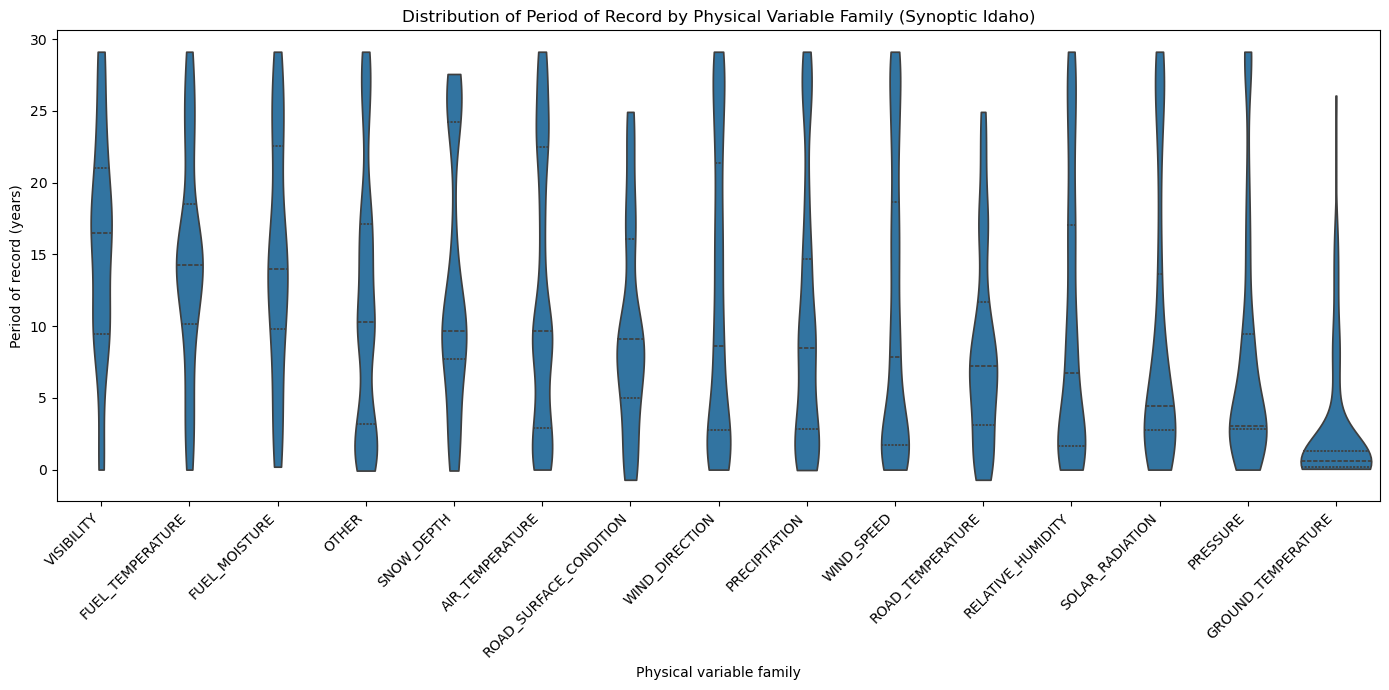

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assicurati che por_years esista
if "por_years" not in df_var_enr.columns:
    print("por_years column missing")

dfp = df_var_enr.dropna(subset=["por_years"]).copy()

# Usa classificazione fisica
fam_counts = dfp["physical_family"].value_counts()

# Tieni solo famiglie con almeno 30 osservazioni
keep_fams = fam_counts[fam_counts >= 30].index
dfp = dfp[dfp["physical_family"].isin(keep_fams)]

# Ordina famiglie per mediana POR
order = (
    dfp.groupby("physical_family")["por_years"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14,7))

sns.violinplot(
    data=dfp,
    x="physical_family",
    y="por_years",
    order=order,
    inner="quartile",
    cut=0
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Physical variable family")
plt.ylabel("Period of record (years)")
plt.title("Distribution of Period of Record by Physical Variable Family (Synoptic Idaho)")
plt.tight_layout()
plt.show()



## Interpretation of Period-of-Record Distribution

The violin plot reveals substantial differences in temporal continuity across physical variable families.

Core atmospheric variables such as **Air Temperature, Wind Speed, Wind Direction, Relative Humidity, and Precipitation** exhibit relatively high median periods of record and comparatively dense distributions. This indicates that many stations reporting these variables have sustained multi-year observational histories.

In particular, **Precipitation** shows strong temporal continuity across a broad portion of the network, with a concentrated distribution in the mid-to-upper range of record lengths. This suggests that precipitation monitoring has been operationally maintained for extended periods at many stations.

Similarly, wind-related variables display consistent record lengths, reflecting their importance in operational meteorology and network design.

In contrast, more specialized variables (e.g., road temperature, fuel moisture, ground temperature) show shorter and more heterogeneous periods of record, consistent with targeted deployment strategies rather than systematic statewide coverage.

Overall, the distribution highlights that the longest and most stable records are associated with core atmospheric measurements, while specialized variables tend to have more recent or variable deployment histories.


## Period-of-Record (POR) Metadata Completeness by Network

This figure evaluates **metadata completeness of the POR **, not data completeness or other metadata

For each Synoptic network (identified by MNET_ID), we compute the percentage of **unique variables** for which the API provides Period-of-Record (POR) metadata. POR metadata typically includes the start and end dates of available observations.

The completeness metric is defined as:

\[
\text{POR completeness (\%)} =
\frac{\text{Number of unique variables with POR metadata}}
{\text{Total number of unique variables in the network}} \times 100
\]

Only networks reporting at least 10 unique variables are included in this comparison to avoid distortions from very small networks.

### Important Clarification

This metric measures:
- The presence of documented temporal metadata,
- The consistency of metadata reporting within each network.

It does **not** measure:
- Data availability or coverage,
- Length of the actual data record,
- Data quality or continuity.

Therefore, this figure reflects how well networks document their variable history, rather than how long or how complete the observational records are.

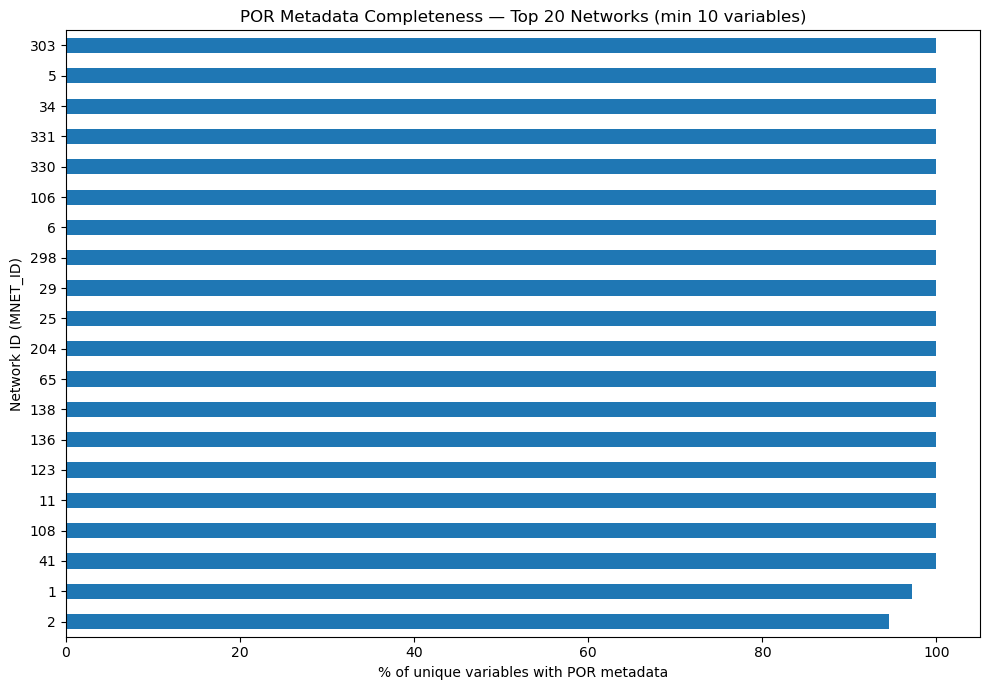

In [15]:
tmp = df_var_enr.copy()
tmp["has_por"] = tmp["por_years"].notna()

por_completeness = (
    tmp.groupby("network_id")
    .agg(
        n_variables=("variable_native", "nunique"),
        n_with_por=("variable_native", lambda s: s[tmp.loc[s.index, "has_por"]].nunique()),
        n_stations=("station_uid", "nunique"),
    )
)

por_completeness["por_completeness_pct"] = (
    por_completeness["n_with_por"] / por_completeness["n_variables"] * 100
)

# opzionale: filtra reti troppo piccole (altrimenti top è pieno di reti con 1–2 variabili)
MIN_VARS = 10
por_completeness_f = por_completeness[por_completeness["n_variables"] >= MIN_VARS] \
    .sort_values("por_completeness_pct", ascending=False)

topN = 20

plt.figure(figsize=(10,7))
por_completeness_f.head(topN)["por_completeness_pct"].iloc[::-1].plot(kind="barh")
plt.xlabel("% of unique variables with POR metadata")
plt.ylabel("Network ID (MNET_ID)")
plt.title(f"POR Metadata Completeness — Top {topN} Networks (min {MIN_VARS} variables)")
plt.tight_layout()
plt.show()


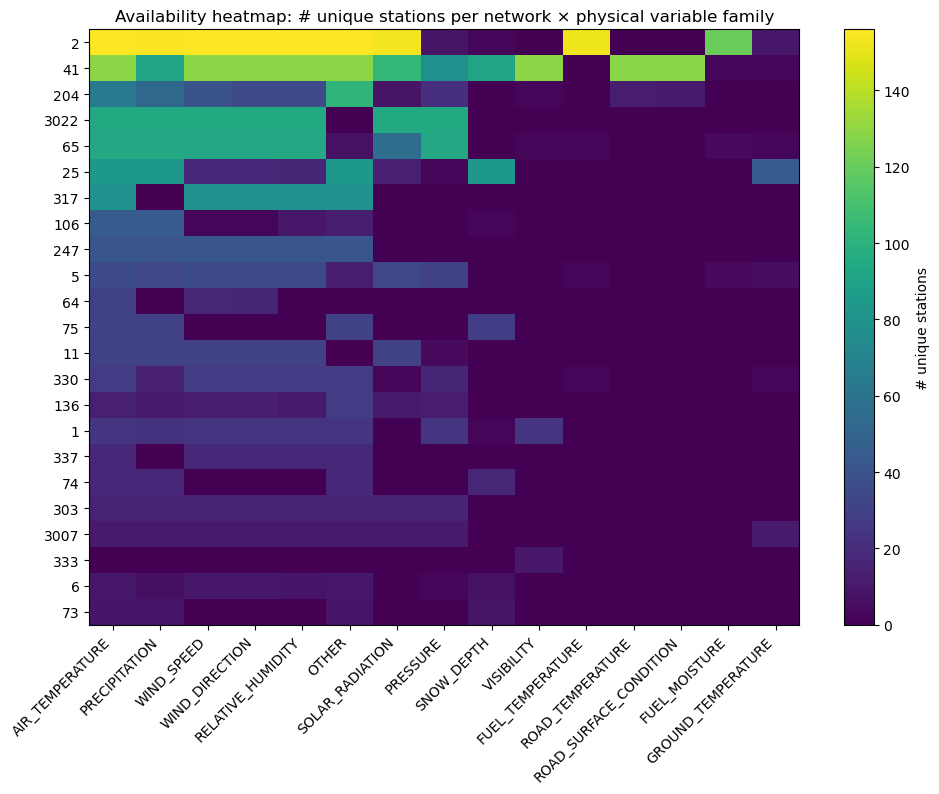

physical_family,AIR_TEMPERATURE,PRECIPITATION,WIND_SPEED,WIND_DIRECTION,RELATIVE_HUMIDITY,OTHER,SOLAR_RADIATION,PRESSURE,SNOW_DEPTH,VISIBILITY,FUEL_TEMPERATURE,ROAD_TEMPERATURE,ROAD_SURFACE_CONDITION,FUEL_MOISTURE,GROUND_TEMPERATURE
network_id,,,,,,,,,,,,,,,
2,156,155,156,156,156,156,153,8,3,0,152,0,0,121,10
41,129,91,129,129,129,129,104,78,91,129,1,128,128,2,2
204,64,52,40,36,36,102,8,21,0,2,0,12,11,0,0
3022,95,95,95,95,95,0,95,95,0,0,0,0,0,0,0
65,94,94,94,94,94,7,56,94,0,2,2,0,0,4,3


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Availability heatmap: # unique stations per network × physical family
# (uses df_var_enr where you already have physical_family like WIND_SPEED)
# ------------------------------------------------------------

# 1) Ensure ids are clean strings
vr = df_var_enr.copy()
vr["network_id"] = vr["network_id"].astype(str).str.strip()
vr["station_uid"] = vr["station_uid"].astype(str).str.strip()

# 2) Require the classification to exist
if "physical_family" not in vr.columns:
    raise KeyError("df_var_enr must contain a 'physical_family' column (e.g., WIND_SPEED).")

# (optional) drop UNKNOWN/NA families if you want a cleaner matrix
vr = vr.dropna(subset=["network_id", "station_uid", "physical_family"])
# vr = vr[vr["physical_family"] != "OTHER"]   # <- uncomment if you want to exclude OTHER

# 3) Build pivot: rows=network_id, cols=physical_family, values=# unique stations
pivot = (
    vr.groupby(["network_id", "physical_family"])["station_uid"]
      .nunique()
      .unstack(fill_value=0)
)

# 4) Keep only networks with enough stations (>= 5) to avoid tiny rows
st = df_station_enr.copy()
st["network_id"] = st["network_id"].astype(str).str.strip()
net_station_counts = st.groupby("network_id")["station_uid"].nunique()
keep_nets = net_station_counts[net_station_counts >= 5].index

pivot = pivot.loc[pivot.index.intersection(keep_nets)]

# 5) If everything got filtered out, show a helpful message
if pivot.shape[0] == 0 or pivot.shape[1] == 0:
    raise ValueError(
        f"Pivot is empty after filtering. Rows={pivot.shape[0]}, Cols={pivot.shape[1]}. "
        "Check that df_station_enr network_id matches df_var_enr network_id and that physical_family exists."
    )

# 6) Order networks by size (descending) and families by overall availability (descending)
pivot = pivot.loc[net_station_counts.loc[pivot.index].sort_values(ascending=False).index]
pivot = pivot[pivot.sum(axis=0).sort_values(ascending=False).index]

# 7) Plot
fig_h = max(6, 0.35 * pivot.shape[0])   # scale height with # networks
fig_w = max(10, 0.55 * pivot.shape[1])  # scale width with # families

plt.figure(figsize=(fig_w, fig_h))
im = plt.imshow(pivot.values, aspect="auto")

plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=45, ha="right")
plt.yticks(range(pivot.shape[0]), pivot.index)

plt.colorbar(im, label="# unique stations")
plt.title("Availability heatmap: # unique stations per network × physical variable family")
plt.tight_layout()
plt.show()

# (optional) Inspect the pivot as a table
pivot.head()

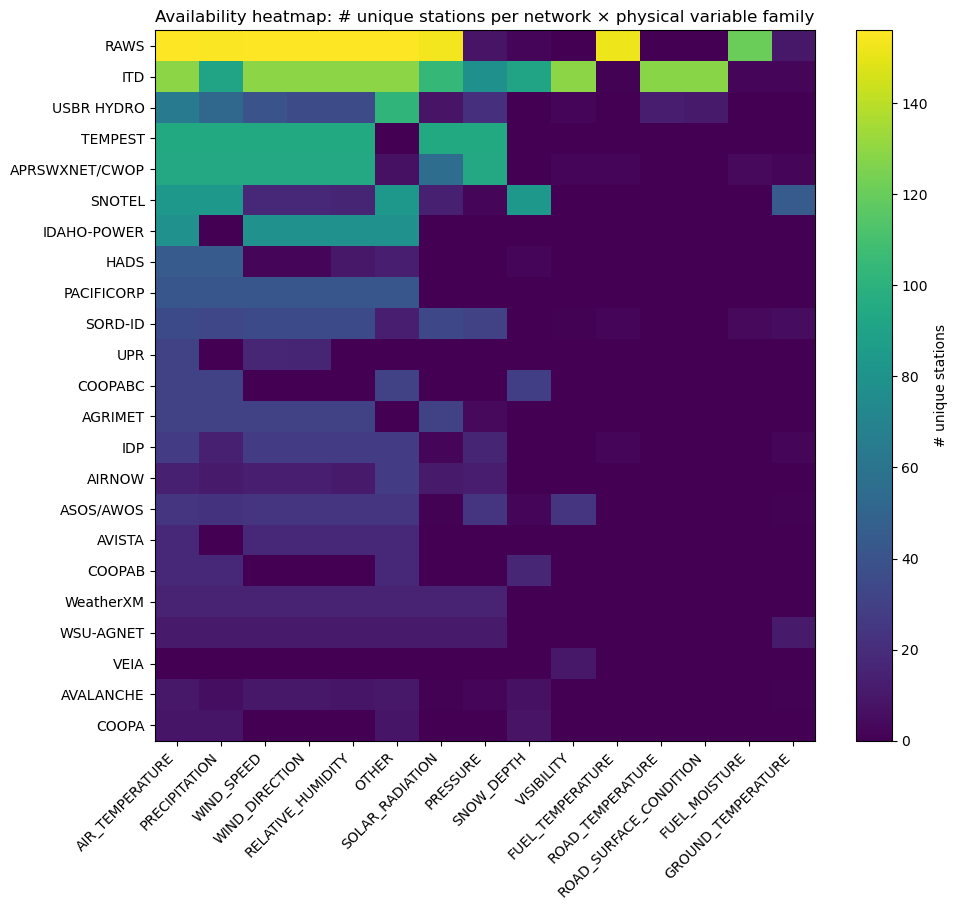

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Prepare variable table
# ------------------------------------------------------------

vr = df_var_enr.copy()
vr["network_id"] = vr["network_id"].astype(str).str.strip()
vr["station_uid"] = vr["station_uid"].astype(str).str.strip()

# require physical_family
if "physical_family" not in vr.columns:
    raise KeyError("df_var_enr must contain 'physical_family'.")

vr = vr.dropna(subset=["network_id", "station_uid", "physical_family"])

# ------------------------------------------------------------
# 2) Build pivot (network × physical family)
# ------------------------------------------------------------

pivot = (
    vr.groupby(["network_id", "physical_family"])["station_uid"]
      .nunique()
      .unstack(fill_value=0)
)

# ------------------------------------------------------------
# 3) Keep only networks with >=5 stations
# ------------------------------------------------------------

st = df_station_enr.copy()
st["network_id"] = st["network_id"].astype(str).str.strip()

net_station_counts = st.groupby("network_id")["station_uid"].nunique()
keep_nets = net_station_counts[net_station_counts >= 5].index

pivot = pivot.loc[pivot.index.intersection(keep_nets)]

# ------------------------------------------------------------
# 4) Load network metadata (for readable names)
# ------------------------------------------------------------

net_meta = pd.read_csv("out/networks_in_idaho.csv")
net_meta["mnet_id"] = net_meta["mnet_id"].astype(str).str.strip()

def build_label(row):
    candidates = [
        row.get("SHORTNAME"),
        row.get("network_shortname"),
        row.get("LONGNAME"),
        row.get("network_name"),
        row.get("NAME"),
        row.get("name"),
    ]
    for c in candidates:
        if c is None:
            continue
        s = str(c).strip()
        if s and s.lower() != "nan":
            return s
    return f"MNET {row.get('mnet_id','')}"

net_meta["network_label"] = net_meta.apply(build_label, axis=1)

id_to_label = dict(zip(net_meta["mnet_id"], net_meta["network_label"]))

# replace index with readable label
pivot.index = pivot.index.map(lambda x: id_to_label.get(x, f"MNET {x}"))

# ------------------------------------------------------------
# 5) Order by network size and family prevalence
# ------------------------------------------------------------

pivot = pivot.loc[
    net_station_counts.loc[keep_nets]
    .sort_values(ascending=False)
    .index
    .map(lambda x: id_to_label.get(x, f"MNET {x}"))
]

pivot = pivot[pivot.sum(axis=0).sort_values(ascending=False).index]

# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------

fig_h = max(6, 0.4 * pivot.shape[0])
fig_w = max(10, 0.6 * pivot.shape[1])

plt.figure(figsize=(fig_w, fig_h))
im = plt.imshow(pivot.values, aspect="auto")

plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=45, ha="right")
plt.yticks(range(pivot.shape[0]), pivot.index)

plt.colorbar(im, label="# unique stations")
plt.title("Availability heatmap: # unique stations per network × physical variable family")
plt.tight_layout()
plt.show()

### Availability Heatmap — Network × Physical Variable Family

This heatmap shows the number of unique stations within each network that report at least one variable belonging to a given physical family (e.g., air temperature, wind speed, precipitation, snow depth).

Rows represent observational networks (e.g., RAWS, ITD, SNOTEL), and columns represent physical variable families. Color intensity indicates how many stations in that network measure that variable family.

This figure provides a structural inventory view of observational capacity across networks. It reflects instrumentation breadth and thematic specialization, but does not assess data quality, continuity, or measurement performance.

In [18]:
df_var_enr = pd.read_csv(OUT_VAR_ENRICHED)
print("Variable rows:", len(df_var_enr))
df_var_enr[["variable_family","variable_native","sensor_height_m","period_of_record_json"]].head(100)

Variable rows: 11674


,variable_family,variable_native,sensor_height_m,period_of_record_json
0,air_temp,air_temp_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
1,relative_humidity,relative_humidity_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
2,wind_speed,wind_speed_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
3,wind_direction,wind_direction_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
4,wind_gust,wind_gust_1,NaN,"{""start"": ""2025-06-06T14:30:00Z"", ""end"": ""2026..."
...,...,...,...,...
95,wind_gust,wind_gust_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."
96,volt,volt_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."
97,air_temp,air_temp_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."
98,dew_point_temperature,dew_point_temperature_1,NaN,"{""start"": ""2026-01-16T22:20:00Z"", ""end"": ""2026..."


In [19]:
print("Columns:", df_var_enr.columns.tolist())

print("\nNon-null % (key fields):")
for c in ["period_of_record_json","sensor_height_m","sensor_depth_m","position","dimension_json","unit"]:
    if c in df_var_enr.columns:
        print(c, ":", round(100*df_var_enr[c].notna().mean(), 2))

print("\nExample period_of_record_json values:")
print(df_var_enr["period_of_record_json"].dropna().head(5).tolist())

print("\nExample sensor_height_m values:")
print(df_var_enr["sensor_height_m"].dropna().head(10).tolist())

print("\nHow many variables have any POR JSON-like content (not {}, [], null)?")
s = df_var_enr["period_of_record_json"].astype("string")
por_present = s.notna() & (~s.str.strip().isin(["", "{}", "[]", "null", "None", "<NA>"]))
print(int(por_present.sum()), "of", len(df_var_enr), "(", round(100*por_present.mean(),2), "% )")

Columns: ['station_uid', 'source', 'source_station_id', 'network_id', 'variable_family', 'variable_native', 'unit', 'sensor_height_m', 'sensor_depth_m', 'position', 'dimension_json', 'period_of_record_json', 'source_details_json']

Non-null % (key fields):
period_of_record_json : 100.0
sensor_height_m : 0.0
sensor_depth_m : 0.0
position : 16.04
dimension_json : 100.0
unit : 0.0

Example period_of_record_json values:
['{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}', '{"start": "2025-06-06T14:30:00Z", "end": "2026-02-17T18:10:00Z"}']

Example sensor_height_m values:
[]

How many variables have any POR JSON-like content (not {}, [], null)?
11674 of 11674 ( 100.0 % )


In [20]:
def observational_metadata_baseline_by_network(df_station_enr, df_var_enr):

    st = df_station_enr.copy()
    vr = df_var_enr.copy()

    st["network_id"] = st["network_id"].astype(str).str.strip()
    vr["network_id"] = vr["network_id"].astype(str).str.strip()

    rows = []

    for mnet_id, g_st in st.groupby("network_id"):
        n_st = int(g_st["station_uid"].nunique())
        g_vr = vr[vr["network_id"] == mnet_id]
        n_var = len(g_vr)

        # --- Station level ---
        provider_transparency = (
            (g_st["providers_json"].astype("string")
             .str.strip()
             .isin(["", "[]", "{}", "null", "None"]) == False).mean()
            if n_st else 0.0
        )

        siting_info = (
            (g_st["siting_json"].astype("string")
             .str.strip()
             .isin(["", "[]", "{}", "null", "None"]) == False).mean()
            if n_st else 0.0
        )

        # --- Variable level ---
        variable_inventory = 1.0 if n_var > 0 else 0.0

        period_of_record = (
            (g_vr["period_of_record_json"].astype("string")
             .str.strip()
             .isin(["", "[]", "{}", "null", "None"]) == False).mean()
            if n_var else 0.0
        )

        sensor_height = (
            g_vr["sensor_height_m"].notna().mean()
            if n_var else 0.0
        )

        # Synoptic API does not expose these consistently
        qaqc_info = 0.0
        network_policy = 0.0

        rows.append({
            "mnet_id": mnet_id,
            "n_stations": n_st,
            "variable_inventory_pct": round(100 * variable_inventory, 2),
            "period_of_record_pct": round(100 * period_of_record, 2),
            "sensor_height_pct": round(100 * sensor_height, 2),
            "qaqc_info_pct": round(100 * qaqc_info, 2),
            "siting_info_pct": round(100 * siting_info, 2),
            "provider_transparency_pct": round(100 * provider_transparency, 2),
            "network_policy_pct": round(100 * network_policy, 2),
        })

    out = pd.DataFrame(rows).sort_values("n_stations", ascending=False)
    out["generated_utc"] = pd.Timestamp.now("UTC").isoformat()
    return out

In [21]:
meta_obs = observational_metadata_baseline_by_network(df_station_enr, df_var_enr)
meta_obs.to_csv(OUT_BASELINE_BY_NET, index=False)
meta_obs.head(12)

,mnet_id,n_stations,variable_inventory_pct,period_of_record_pct,sensor_height_pct,qaqc_info_pct,siting_info_pct,provider_transparency_pct,network_policy_pct,generated_utc
9,2,156,100.0,100.0,0.0,0.0,0.0,96.15,0.0,2026-02-19T21:29:15.493306+00:00
25,41,129,100.0,100.0,0.0,0.0,0.0,100.00,0.0,2026-02-19T21:29:15.493306+00:00
10,204,116,100.0,100.0,0.0,0.0,0.0,0.00,0.0,2026-02-19T21:29:15.493306+00:00
17,3022,95,100.0,100.0,0.0,0.0,0.0,0.00,0.0,2026-02-19T21:29:15.493306+00:00
31,65,94,100.0,100.0,0.0,0.0,0.0,93.62,0.0,2026-02-19T21:29:15.493306+00:00
12,25,83,100.0,100.0,0.0,0.0,0.0,96.39,0.0,2026-02-19T21:29:15.493306+00:00
19,317,79,100.0,100.0,0.0,0.0,0.0,0.00,0.0,2026-02-19T21:29:15.493306+00:00
1,106,52,100.0,100.0,0.0,0.0,0.0,92.31,0.0,2026-02-19T21:29:15.493306+00:00
11,247,42,100.0,100.0,0.0,0.0,0.0,83.33,0.0,2026-02-19T21:29:15.493306+00:00
27,5,35,100.0,100.0,0.0,0.0,0.0,80.00,0.0,2026-02-19T21:29:15.493306+00:00


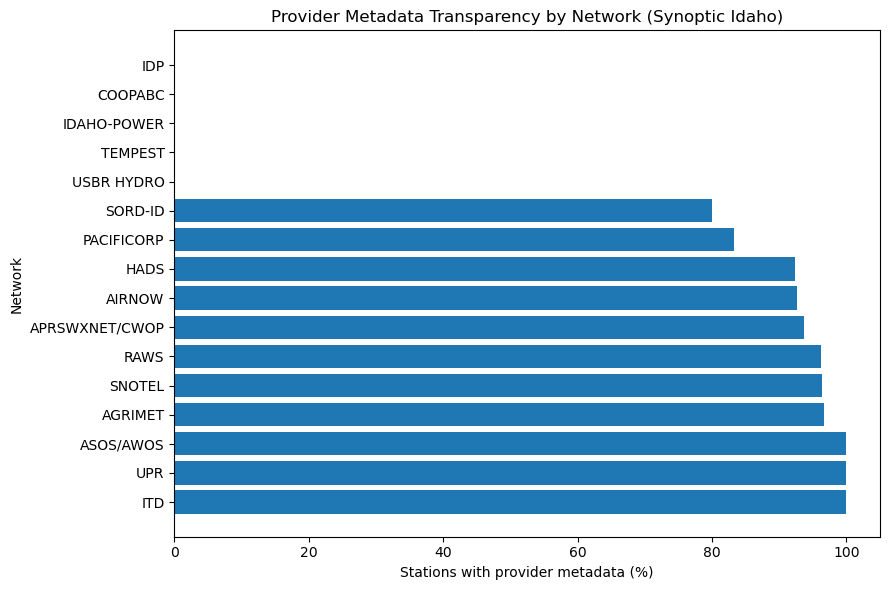

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Start from meta_obs ---
df = meta_obs.copy()

# --- Load network labels ---
net = pd.read_csv("out/networks_in_idaho.csv")
net["mnet_id"] = net["mnet_id"].astype(str).str.strip()

def build_label(row):
    candidates = [
        row.get("SHORTNAME"),
        row.get("network_shortname"),
        row.get("LONGNAME"),
        row.get("network_name"),
        row.get("NAME"),
        row.get("name"),
    ]
    for c in candidates:
        if c is None:
            continue
        s = str(c).strip()
        if s and s.lower() != "nan":
            return s
    return f"MNET {row.get('mnet_id','')}"

net["network_label"] = net.apply(build_label, axis=1)

# --- Merge readable names ---
df["mnet_id"] = df["mnet_id"].astype(str).str.strip()
df = df.merge(
    net[["mnet_id", "network_label"]],
    on="mnet_id",
    how="left"
)

df["network_label"] = df["network_label"].fillna("MNET " + df["mnet_id"])

# --- Keep networks with >=20 stations ---
df = df[df["n_stations"] >= 20].copy()

# --- Sort by provider transparency ---
df = df.sort_values("provider_transparency_pct", ascending=False)

# --- Plot ---
plt.figure(figsize=(9,6))

plt.barh(
    df["network_label"],
    df["provider_transparency_pct"]
)

plt.xlabel("Stations with provider metadata (%)")
plt.ylabel("Network")
plt.title("Provider Metadata Transparency by Network (Synoptic Idaho)")

plt.tight_layout()
plt.show()
plt.show()

In [23]:
import pandas as pd
import numpy as np

# -----------------------------
# Variable coverage by network (station-level)
# -----------------------------
key_vars = {
    "air_temp": ["air_temp"],
    "precip": ["precip"],
    "wind": ["wind_speed", "wind_gust", "wind_dir", "wind_direction"],
    "snow": ["snow_depth", "snow_water_equiv", "snow_water_equivalent"],
    "radiation": ["solar_radiation", "shortwave", "radiation"],
    "soil": ["soil_temp", "soil_moisture"],
}

vr = df_var_enr.copy()
vr["network_id"] = vr["network_id"].astype(str).str.strip()
vr["station_uid"] = vr["station_uid"].astype(str).str.strip()
vr["variable_family"] = vr["variable_family"].astype(str)

rows = []

for net, g in vr.groupby("network_id"):
    rec = {"network_id": net}

    # denominatore: quante stazioni nel network (secondo df_station_enr è meglio, ma qui coerente con vr)
    stations_in_net = g["station_uid"].nunique()
    rec["n_stations_in_vr"] = stations_in_net

    for label, families in key_vars.items():
        pat = "|".join([f for f in families if f])
        # stazioni che hanno ALMENO 1 variabile che matcha la categoria
        st_with_var = g.loc[g["variable_family"].str.contains(pat, case=False, na=False), "station_uid"].nunique()
        rec[f"{label}_station_coverage_pct"] = round(100 * st_with_var / stations_in_net, 2) if stations_in_net else np.nan

    rows.append(rec)

var_cov = pd.DataFrame(rows)

# -----------------------------
# Join with station table counts (recommended denominator)
# -----------------------------
st = df_station_enr.copy()
st["network_id"] = st["network_id"].astype(str).str.strip()
net_counts = st.groupby("network_id")["station_uid"].nunique().rename("n_stations").reset_index()

var_cov = var_cov.merge(net_counts, on="network_id", how="left")

# -----------------------------
# Add readable network names
# -----------------------------
net = pd.read_csv("out/networks_in_idaho.csv")
net["mnet_id"] = net["mnet_id"].astype(str).str.strip()

def build_label(row):
    candidates = [
        row.get("SHORTNAME"),
        row.get("network_shortname"),
        row.get("LONGNAME"),
        row.get("network_name"),
        row.get("NAME"),
        row.get("name"),
    ]
    for c in candidates:
        if c is None:
            continue
        s = str(c).strip()
        if s and s.lower() != "nan":
            return s
    return f"MNET {row.get('mnet_id','')}"

net["network_label"] = net.apply(build_label, axis=1)
var_cov = var_cov.merge(net[["mnet_id", "network_label"]], left_on="network_id", right_on="mnet_id", how="left")
var_cov["network_label"] = var_cov["network_label"].fillna("MNET " + var_cov["network_id"])

# sort by station count
var_cov = var_cov.sort_values("n_stations", ascending=False)

var_cov.head(12)

,network_id,n_stations_in_vr,air_temp_station_coverage_pct,precip_station_coverage_pct,wind_station_coverage_pct,snow_station_coverage_pct,radiation_station_coverage_pct,soil_station_coverage_pct,n_stations,mnet_id,network_label
9,2,156,100.00,99.36,100.00,1.92,98.08,7.05,156,2,RAWS
25,41,129,100.00,70.54,100.00,70.54,80.62,1.55,129,41,ITD
10,204,116,47.41,44.83,36.21,0.00,6.90,0.00,116,204,USBR HYDRO
17,3022,95,100.00,100.00,100.00,0.00,100.00,0.00,95,3022,TEMPEST
31,65,94,100.00,100.00,100.00,0.00,59.57,3.19,94,65,APRSWXNET/CWOP
12,25,83,100.00,100.00,21.69,100.00,16.87,54.22,83,25,SNOTEL
19,317,79,100.00,0.00,100.00,0.00,0.00,0.00,79,317,IDAHO-POWER
1,106,52,75.00,86.54,5.77,7.69,0.00,9.62,52,106,HADS
11,247,42,100.00,100.00,100.00,0.00,0.00,0.00,42,247,PACIFICORP
27,5,35,100.00,94.29,100.00,0.00,97.14,14.29,35,5,SORD-ID


In [24]:
COVERAGE_CSV = os.path.join(OUT_DIR, "variable_coverage_by_network.csv")

var_cov.to_csv(COVERAGE_CSV, index=False)

print("[OUT]", COVERAGE_CSV, len(var_cov))

[OUT] out/variable_coverage_by_network.csv 41


## Mean nearest-neighbor distance (km)

## 95th percentile distance (km)

In [25]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = syn[["latitude","longitude"]].dropna().values

nn = NearestNeighbors(n_neighbors=2, metric="haversine")
nn.fit(np.radians(coords))

distances, _ = nn.kneighbors(np.radians(coords))
dist_km = distances[:,1] * 6371

print("Mean nearest-neighbor distance (km):", dist_km.mean())
print("95th percentile distance (km):", np.percentile(dist_km,95))

Mean nearest-neighbor distance (km): 4.760384752474536
95th percentile distance (km): 15.726581370137671


## Synoptic stations show strong clustering behavior, with a mean nearest-neighbor distance of ~4.8 km.
However, the 95th percentile distance (~15.7 km) indicates that a non-negligible fraction of stations are spatially isolated, 
suggesting heterogeneous coverage

## Mean nearest-neighbor distance (km)

## 95th percentile distance (km)

Nearest-neighbor distance percentiles (km):
P5: 0.00 km
P25: 0.88 km
P50: 2.79 km
P75: 6.72 km
P90: 11.27 km
P95: 15.73 km
P99: 27.44 km


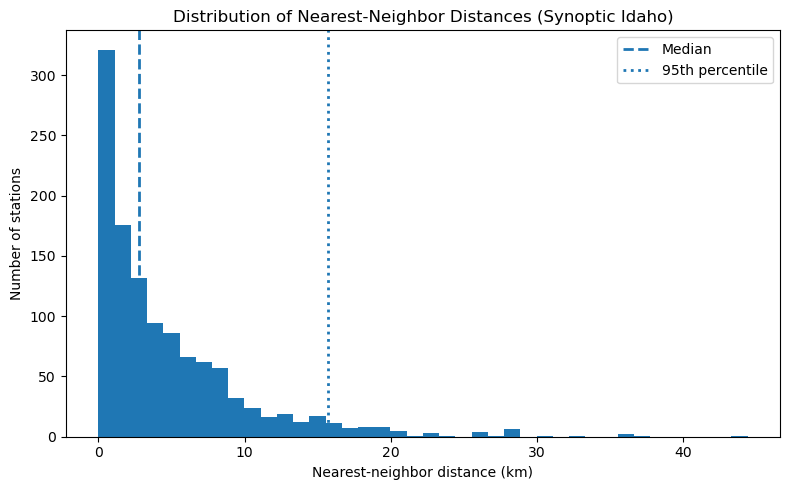

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Recompute percentiles ---
percentiles = [5, 25, 50, 75, 90, 95, 99]
perc_values = {p: np.percentile(dist_km, p) for p in percentiles}

print("Nearest-neighbor distance percentiles (km):")
for p, v in perc_values.items():
    print(f"P{p}: {v:.2f} km")

# --- Plot distribution ---
plt.figure(figsize=(8,5))

plt.hist(dist_km, bins=40)
plt.axvline(perc_values[50], linestyle="--", linewidth=2, label="Median")
plt.axvline(perc_values[95], linestyle=":", linewidth=2, label="95th percentile")

plt.xlabel("Nearest-neighbor distance (km)")
plt.ylabel("Number of stations")
plt.title("Distribution of Nearest-Neighbor Distances (Synoptic Idaho)")
plt.legend()

plt.tight_layout()
plt.show()

nn_df rows: 1175


<Figure size 1400x600 with 0 Axes>

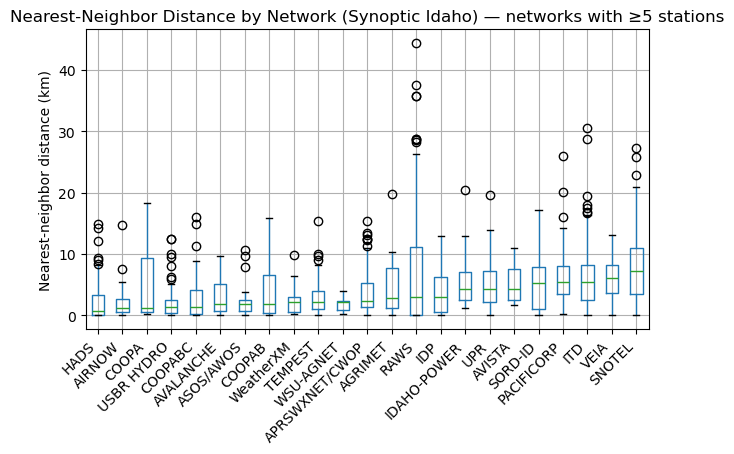

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# 0) Build nn_df from df_station_enr (Synoptic only)
# -----------------------------
st = df_station_enr.copy()
st = st[st["source"].astype(str).str.upper().eq("SYNOPTIC")].copy()

# keep only rows with coords + network_id
st["network_id"] = st["network_id"].astype(str).str.strip()
st = st.dropna(subset=["latitude", "longitude", "network_id"]).copy()

coords = st[["latitude","longitude"]].to_numpy(dtype=float)

# nearest neighbor in haversine (km)
nn = NearestNeighbors(n_neighbors=2, metric="haversine")
nn.fit(np.radians(coords))
distances, _ = nn.kneighbors(np.radians(coords))
nn_km = distances[:, 1] * 6371.0

nn_df = st[["station_uid","source_station_id","network_id"]].copy()
nn_df["nn_distance_km"] = nn_km

print("nn_df rows:", len(nn_df))
nn_df.head()

# -----------------------------
# 1) Load network metadata and build readable labels
# -----------------------------
net = pd.read_csv("out/networks_in_idaho.csv")
net["mnet_id"] = net["mnet_id"].astype(str).str.strip()

def build_label(row):
    for col in ["SHORTNAME","network_shortname","LONGNAME","network_name","NAME","name"]:
        if col in row and pd.notna(row[col]):
            s = str(row[col]).strip()
            if s and s.lower() != "nan":
                return s
    return f"MNET {row.get('mnet_id','')}"

net["network_label_clean"] = net.apply(build_label, axis=1)
id_to_label = dict(zip(net["mnet_id"], net["network_label_clean"]))

nn_df["network_label_clean"] = nn_df["network_id"].map(id_to_label).fillna("MNET " + nn_df["network_id"])

# -----------------------------
# 2) Order by median distance (optional: filter small networks)
# -----------------------------
MIN_STATIONS_PER_NET = 5
net_sizes = nn_df["network_label_clean"].value_counts()
keep = net_sizes[net_sizes >= MIN_STATIONS_PER_NET].index
dfp = nn_df[nn_df["network_label_clean"].isin(keep)].copy()

order = (
    dfp.groupby("network_label_clean")["nn_distance_km"]
    .median()
    .sort_values()
    .index
)

dfp["network_label_clean"] = pd.Categorical(dfp["network_label_clean"], categories=order, ordered=True)
dfp = dfp.sort_values("network_label_clean")

# -----------------------------
# 3) Plot
# -----------------------------
plt.figure(figsize=(14,6))
dfp.boxplot(column="nn_distance_km", by="network_label_clean", rot=45)
plt.suptitle("")
plt.title(f"Nearest-Neighbor Distance by Network (Synoptic Idaho) — networks with ≥{MIN_STATIONS_PER_NET} stations")
plt.xlabel("")
plt.ylabel("Nearest-neighbor distance (km)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Nearest-Neighbor Distance by Network (Synoptic Idaho)

This figure shows the distribution of nearest-neighbor distances (km) between stations within each network (networks with ≥5 stations).

**Interpretation:**

- Networks on the left (e.g., HADS, AIRNOW, COOPA) exhibit very small median distances (≈1–3 km), indicating strong spatial clustering.
- Mid-range networks (e.g., RAWS, IDP, IDAHO-POWER) show moderate spacing, with broader interquartile ranges, reflecting mixed clustering and dispersion.
- Networks toward the right (e.g., VEIA, SNOTEL) have larger median distances and wider spreads, indicating more spatially dispersed station layouts.
- Several networks show long upper tails (outliers >20–40 km), revealing isolated stations even within otherwise dense networks.

**Overall pattern:**
Synoptic networks in Idaho range from highly clustered (urban/mesoscale-focused systems) to spatially distributed (hydrologic or terrain-driven networks), reflecting different monitoring objectives and deployment strategies.

In [34]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

# -----------------------------
# 0) Ensure physical_family exists
# -----------------------------
if "physical_family" not in df_var_enr.columns:
    def classify_physical_family(row):
        fam = str(row.get("variable_family", "")).lower()
        nat = str(row.get("variable_native", "")).lower()
        s = fam + " " + nat

        # order matters (more specific first)
        if "snow" in s and ("depth" in s or "snow_depth" in s):
            return "SNOW_DEPTH"
        if "snow" in s and ("water_equiv" in s or "swe" in s):
            return "SWE"
        if "precip" in s:
            return "PRECIPITATION"
        if "air_temp" in s or "temperature" in s and "road" not in s and "soil" not in s and "fuel" not in s:
            return "AIR_TEMPERATURE"
        if "relative_humidity" in s or "rh" == fam:
            return "RELATIVE_HUMIDITY"
        if "wind_speed" in s or "wind_gust" in s:
            return "WIND_SPEED"
        if "wind_dir" in s or "wind_direction" in s:
            return "WIND_DIRECTION"
        if "solar" in s or "radiation" in s or "shortwave" in s:
            return "SOLAR_RADIATION"
        if "pressure" in s or "altimeter" in s or "sea_level_pressure" in s:
            return "PRESSURE"
        return "OTHER"

    df_var_enr = df_var_enr.copy()
    df_var_enr["physical_family"] = df_var_enr.apply(classify_physical_family, axis=1)

print("physical_family column ready. Example counts:")
print(df_var_enr["physical_family"].value_counts().head(12))

# -----------------------------
# 1) Compute NN distance stats by physical family
# -----------------------------
families = [
    "AIR_TEMPERATURE",
    "PRECIPITATION",
    "WIND_SPEED",
    "WIND_DIRECTION",
    "RELATIVE_HUMIDITY",
    "SOLAR_RADIATION",
    "PRESSURE",
    "SNOW_DEPTH",
]

records = []

# make sure station_uid exists in both
assert "station_uid" in df_var_enr.columns
assert "station_uid" in syn.columns

for fam in families:
    st_ids = df_var_enr.loc[df_var_enr["physical_family"] == fam, "station_uid"].dropna().unique()

    coords = (
        syn.loc[syn["station_uid"].isin(st_ids), ["latitude", "longitude"]]
        .dropna()
        .to_numpy()
    )

    if len(coords) < 5:
        records.append({
            "family": fam, "n_stations": len(coords),
            "median_km": np.nan, "p90_km": np.nan, "p95_km": np.nan
        })
        continue

    nn = NearestNeighbors(n_neighbors=2, metric="haversine")
    nn.fit(np.radians(coords))
    distances, _ = nn.kneighbors(np.radians(coords))
    dist_km = distances[:, 1] * 6371.0

    records.append({
        "family": fam,
        "n_stations": int(len(coords)),
        "median_km": float(np.median(dist_km)),
        "p90_km": float(np.percentile(dist_km, 90)),
        "p95_km": float(np.percentile(dist_km, 95)),
    })

dist_df = pd.DataFrame(records).sort_values("median_km", na_position="last")
dist_df

physical_family column ready. Example counts:
physical_family
OTHER                3244
WIND_SPEED           1905
AIR_TEMPERATURE      1654
PRECIPITATION        1443
WIND_DIRECTION       1052
RELATIVE_HUMIDITY     857
PRESSURE              608
SOLAR_RADIATION       562
SNOW_DEPTH            259
SWE                    90
Name: count, dtype: int64


,family,n_stations,median_km,p90_km,p95_km
1,PRECIPITATION,880,3.284748,14.311951,18.384163
0,AIR_TEMPERATURE,1078,3.321790,12.328736,16.120450
4,RELATIVE_HUMIDITY,856,3.977004,14.274752,18.178379
2,WIND_SPEED,873,3.982268,14.473206,18.233551
3,WIND_DIRECTION,866,4.025353,14.504055,18.064431
6,PRESSURE,421,4.212558,17.351401,23.048700
5,SOLAR_RADIATION,546,5.500825,18.678335,26.224329
7,SNOW_DEPTH,259,11.706910,24.837316,32.343118


<Figure size 1000x600 with 0 Axes>

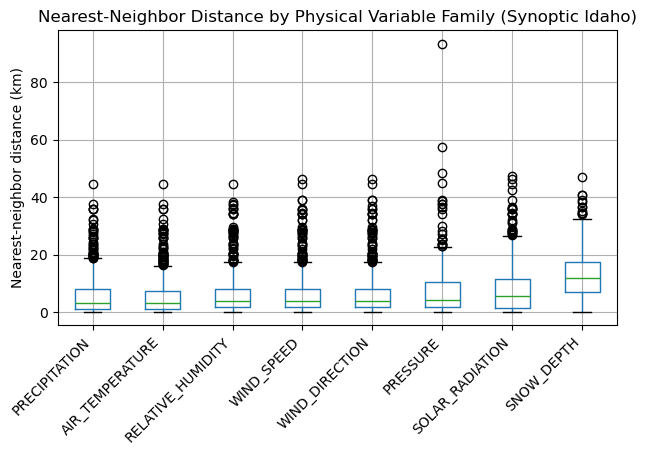

In [36]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

families = [
    "AIR_TEMPERATURE",
    "PRECIPITATION",
    "WIND_SPEED",
    "WIND_DIRECTION",
    "RELATIVE_HUMIDITY",
    "SOLAR_RADIATION",
    "PRESSURE",
    "SNOW_DEPTH",
]

records = []

for fam in families:
    
    st_ids = (
        df_var_enr.loc[df_var_enr["physical_family"] == fam, "station_uid"]
        .dropna()
        .unique()
    )

    coords = (
        syn.loc[syn["station_uid"].isin(st_ids), ["latitude","longitude"]]
        .dropna()
        .to_numpy()
    )

    if len(coords) < 5:
        continue

    nn = NearestNeighbors(n_neighbors=2, metric="haversine")
    nn.fit(np.radians(coords))
    distances, _ = nn.kneighbors(np.radians(coords))
    dist_km = distances[:,1] * 6371.0

    for d in dist_km:
        records.append({
            "family": fam,
            "nn_distance_km": d
        })

dist_long = pd.DataFrame(records)

# Ordina per mediana
order = (
    dist_long.groupby("family")["nn_distance_km"]
    .median()
    .sort_values()
    .index
)

dist_long["family"] = pd.Categorical(
    dist_long["family"],
    categories=order,
    ordered=True
)

dist_long = dist_long.sort_values("family")

# Plot
plt.figure(figsize=(10,6))
dist_long.boxplot(column="nn_distance_km", by="family", rot=45)

plt.suptitle("")
plt.title("Nearest-Neighbor Distance by Physical Variable Family (Synoptic Idaho)")
plt.xlabel("")
plt.ylabel("Nearest-neighbor distance (km)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Nearest-Neighbor Distance by Physical Variable Family (Synoptic Idaho)

This figure shows the distribution of nearest-neighbor station distances (km) for major physical variable families.

**Key patterns:**

- **Precipitation, Air Temperature, Relative Humidity, and Wind variables**  
  These families exhibit relatively small median distances (≈2–6 km), indicating dense spatial coverage and strong clustering.

- **Pressure and Solar Radiation**  
  Slightly higher medians and broader interquartile ranges suggest more moderate spacing and heterogeneous deployment patterns.

- **Snow Depth**  
  Displays the largest median and widest spread, with a long upper tail. This reflects more spatially distributed, terrain-driven station placement typical of snow-monitoring networks.

- **Outliers across all families**  
  Upper tails (>30–90 km) indicate isolated stations even within otherwise dense monitoring systems.

**Overall interpretation:**  
Core meteorological variables are densely monitored across Idaho, while snow-related measurements are more spatially dispersed, reflecting different observational objectives and network design strategies.

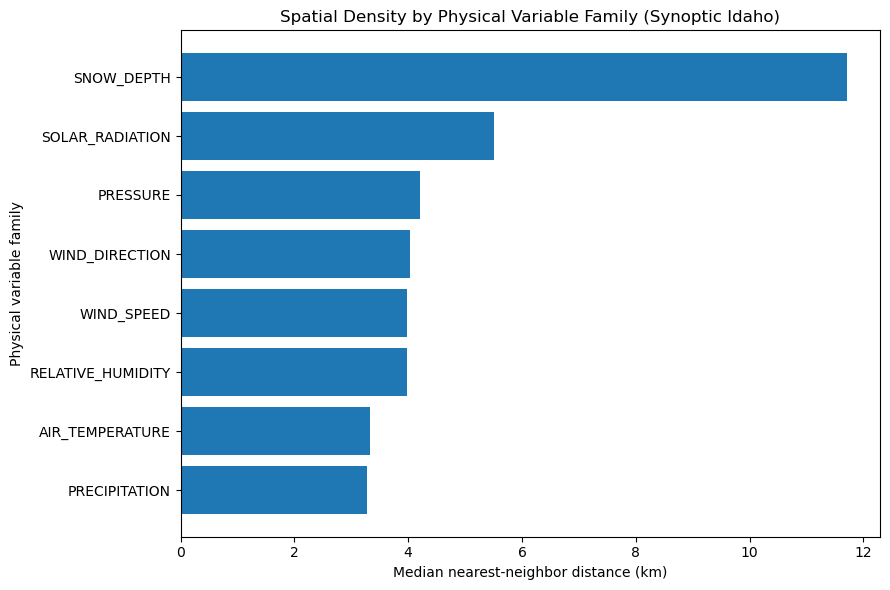

In [37]:
plt.figure(figsize=(9,6))

plt.barh(dist_df["family"], dist_df["median_km"])

plt.xlabel("Median nearest-neighbor distance (km)")
plt.ylabel("Physical variable family")
plt.title("Spatial Density by Physical Variable Family (Synoptic Idaho)")

plt.tight_layout()
plt.show()

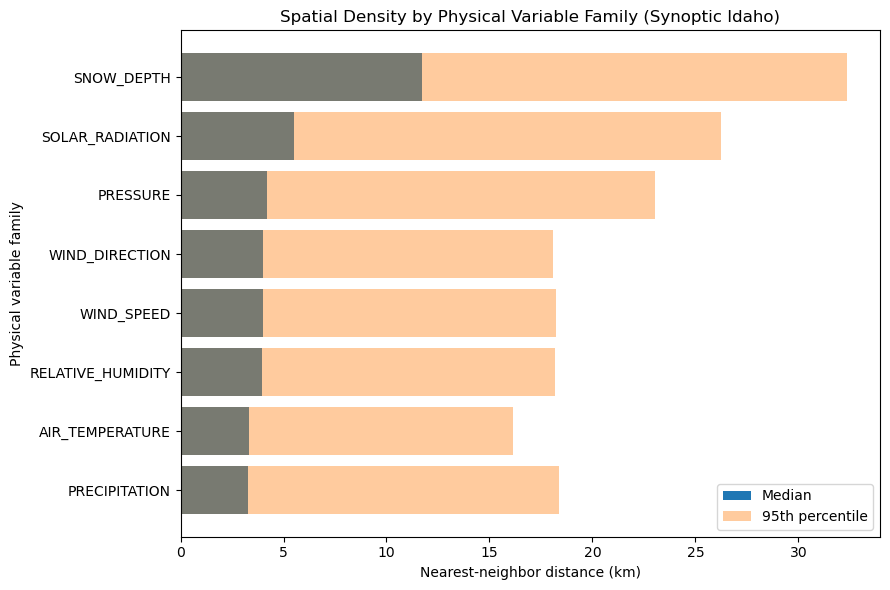

In [38]:
plt.figure(figsize=(9,6))

plt.barh(dist_df["family"], dist_df["median_km"], label="Median")
plt.barh(dist_df["family"], dist_df["p95_km"], alpha=0.4, label="95th percentile")

plt.xlabel("Nearest-neighbor distance (km)")
plt.ylabel("Physical variable family")
plt.title("Spatial Density by Physical Variable Family (Synoptic Idaho)")
plt.legend()

plt.tight_layout()
plt.show()

### Spatial Density by Physical Variable Family (Synoptic Idaho)

This figure summarizes nearest-neighbor station spacing using two metrics:

- **Median distance** → typical spacing between stations  
- **95th percentile distance** → upper-tail spacing (isolated stations)

**Key insights:**

- **Air Temperature, Relative Humidity, Wind, and Precipitation**  
  These variables show low median distances (3–5 km), indicating dense spatial coverage. However, their 95th percentiles (15–20 km) reveal occasional isolated stations.

- **Pressure and Solar Radiation**  
  Slightly higher medians and larger 95th percentiles suggest more heterogeneous deployment patterns.

- **Snow Depth**  
  Displays the largest median (~10+ km) and highest 95th percentile (>30 km), reflecting a more spatially dispersed monitoring network typical of terrain-driven snow observations.

**Overall interpretation:**  
Core meteorological variables are densely monitored across Idaho, while snow-related observations are more spatially distributed, reflecting different monitoring objectives and network design strategies.

In [42]:
print(df.columns.tolist())

['network_id', 'n_stations_in_vr', 'air_temp_station_coverage_pct', 'precip_station_coverage_pct', 'wind_station_coverage_pct', 'snow_station_coverage_pct', 'radiation_station_coverage_pct', 'soil_station_coverage_pct', 'n_stations', 'mnet_id_x', 'network_label', 'mnet_id_y', 'network_label_syn']


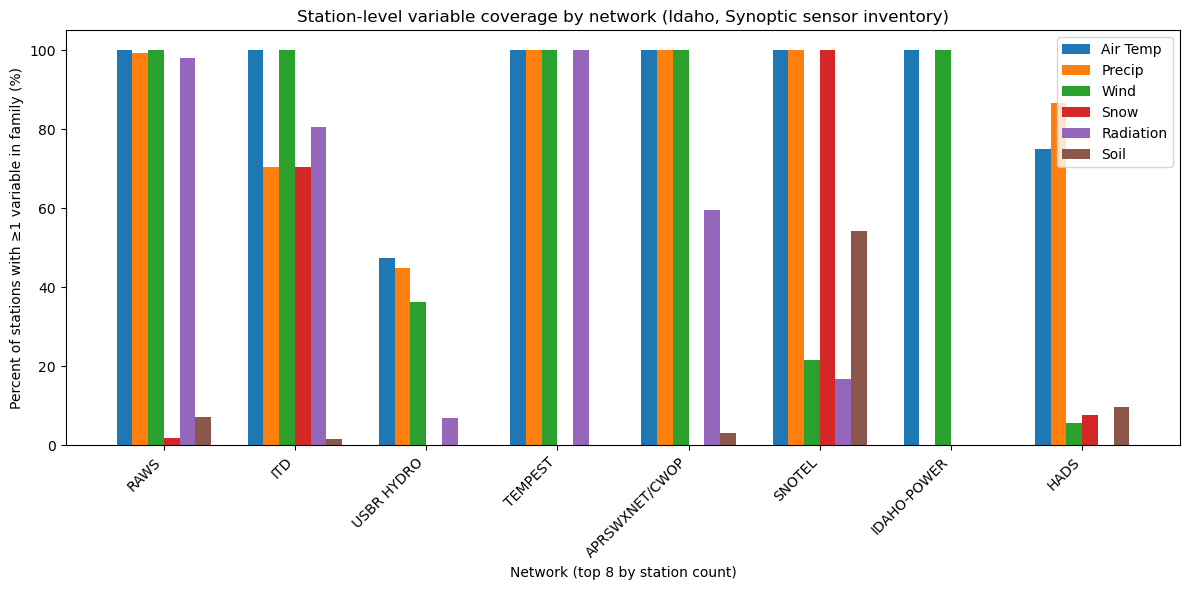

,network_id,network_label_final,n_stations,air_temp_station_coverage_pct,precip_station_coverage_pct,wind_station_coverage_pct,snow_station_coverage_pct,radiation_station_coverage_pct,soil_station_coverage_pct
0,2,RAWS,156,100.00,99.36,100.00,1.92,98.08,7.05
1,41,ITD,129,100.00,70.54,100.00,70.54,80.62,1.55
2,204,USBR HYDRO,116,47.41,44.83,36.21,0.00,6.90,0.00
3,3022,TEMPEST,95,100.00,100.00,100.00,0.00,100.00,0.00
4,65,APRSWXNET/CWOP,94,100.00,100.00,100.00,0.00,59.57,3.19
5,25,SNOTEL,83,100.00,100.00,21.69,100.00,16.87,54.22
6,317,IDAHO-POWER,79,100.00,0.00,100.00,0.00,0.00,0.00
7,106,HADS,52,75.00,86.54,5.77,7.69,0.00,9.62


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

COVERAGE_CSV = "out/variable_coverage_by_network.csv"
df = pd.read_csv(COVERAGE_CSV)

# --- normalize ids ---
df["network_id"] = df["network_id"].astype(str).str.strip()

# --- pick a single label column (prefer network_label, else network_label_syn, else fallback) ---
df["network_label_final"] = df.get("network_label")
if "network_label_final" not in df.columns:
    df["network_label_final"] = np.nan

if "network_label_syn" in df.columns:
    df["network_label_final"] = df["network_label_final"].fillna(df["network_label_syn"])

df["network_label_final"] = df["network_label_final"].fillna("MNET " + df["network_id"])

# --- choose top N networks by station count (use n_stations if present, else n_stations_in_vr) ---
count_col = "n_stations" if "n_stations" in df.columns else "n_stations_in_vr"
TOP_N = 8
dfp = df.sort_values(count_col, ascending=False).head(TOP_N).copy()

variables = [
    "air_temp_station_coverage_pct",
    "precip_station_coverage_pct",
    "wind_station_coverage_pct",
    "snow_station_coverage_pct",
    "radiation_station_coverage_pct",
    "soil_station_coverage_pct",
]
labels = ["Air Temp", "Precip", "Wind", "Snow", "Radiation", "Soil"]

# --- sanity check ---
missing = [v for v in variables if v not in dfp.columns]
if missing:
    raise KeyError(f"Missing expected columns in {COVERAGE_CSV}: {missing}")

# --- grouped bar plot ---
n_vars = len(variables)
x = np.arange(len(dfp))
width = 0.12
offset = (n_vars - 1) / 2 * width

plt.figure(figsize=(12,6))
for i, var in enumerate(variables):
    plt.bar(x + i*width - offset, dfp[var].values, width, label=labels[i])

plt.ylabel("Percent of stations with ≥1 variable in family (%)")
plt.xlabel("Network (top 8 by station count)")
plt.title("Station-level variable coverage by network (Idaho, Synoptic sensor inventory)")
plt.xticks(x, dfp["network_label_final"].values, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# quick table for the caption / sanity
display(dfp[["network_id", "network_label_final", count_col] + variables])

### Station-level Variable Coverage by Network (Idaho, Synoptic Inventory)

This figure shows the percentage of stations within each major Idaho network (top 8 by station count) that report at least one sensor in each physical variable family.

**Key patterns:**

- **RAWS and TEMPEST** exhibit near-complete coverage for core meteorological variables (air temperature, precipitation, wind), indicating broad general-purpose instrumentation.
- **ITD** shows strong coverage across air temperature, wind, snow, and radiation, consistent with transportation-focused monitoring.
- **SNOTEL** is highly specialized, with strong snow and precipitation coverage and moderate soil representation, but limited wind instrumentation.
- **IDAHO-POWER** emphasizes wind and temperature, reflecting energy-sector monitoring priorities.
- **USBR HYDRO** shows moderate precipitation and temperature coverage but limited diversity overall.
- **HADS** provides strong precipitation coverage but lower representation of other variables.

**Overall interpretation:**
Core meteorological variables (temperature, precipitation, wind) are widely represented across most networks, while snow, radiation, and soil measurements show stronger network specialization. This reflects differing observational objectives and deployment strategies across Idaho’s monitoring systems.